In [1]:
!pip install pandas nltk textblob scikit-learn matplotlib

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
df = pd.read_csv("student_feedback.csv")

print(df.head())
print("\nDataset Shape:", df.shape)

                                            Feedback
0  The teaching method is excellent and easy to u...
1         The subject is very interesting and useful
2              The teacher explains concepts clearly
3  The classroom activities are engaging and enjo...
4      The course content is difficult to understand

Dataset Shape: (30, 1)


In [4]:
print(df.isnull().sum())

Feedback    0
dtype: int64


In [5]:
df = df.dropna()

In [6]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df["Cleaned_Feedback"] = df["Feedback"].apply(preprocess_text)

print(df.head())

                                            Feedback  \
0  The teaching method is excellent and easy to u...   
1         The subject is very interesting and useful   
2              The teacher explains concepts clearly   
3  The classroom activities are engaging and enjo...   
4      The course content is difficult to understand   

                                    Cleaned_Feedback  
0  the teaching method is excellent and easy to u...  
1         the subject is very interesting and useful  
2              the teacher explains concepts clearly  
3  the classroom activities are engaging and enjo...  
4      the course content is difficult to understand  


In [7]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"


df["Sentiment"] = df["Cleaned_Feedback"].apply(get_sentiment)

print(df[["Feedback", "Sentiment"]].head(10))

                                            Feedback Sentiment
0  The teaching method is excellent and easy to u...  Positive
1         The subject is very interesting and useful  Positive
2              The teacher explains concepts clearly  Positive
3  The classroom activities are engaging and enjo...  Positive
4      The course content is difficult to understand  Negative
5                     The teaching speed is too fast  Positive
6       The classroom is often noisy and distracting   Neutral
7  The teacher should provide more practical exam...  Positive
8  I am satisfied with the overall learning exper...  Positive
9  The assignments are too difficult and time con...  Negative


In [8]:
sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

Sentiment
Positive    20
Negative     5
Neutral      5
Name: count, dtype: int64


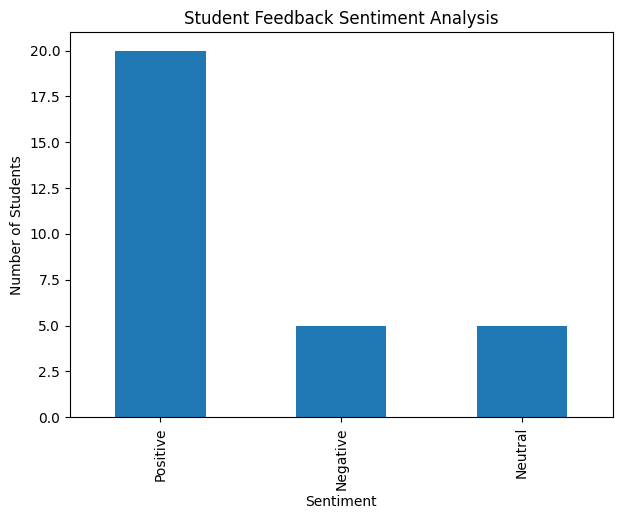

In [9]:
plt.figure(figsize=(7, 5))

sentiment_count.plot(kind="bar")

plt.title("Student Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Students")

plt.show()

In [10]:
concern_keywords = {
    "Teaching Method": [
        "teaching",
        "teacher",
        "lectures",
        "explain"
    ],

    "Subject Difficulty": [
        "difficult",
        "challenging",
        "subject",
        "theoretical"
    ],

    "Classroom Activities": [
        "activities",
        "group",
        "interactive",
        "classroom"
    ],

    "Practical Learning": [
        "practical",
        "examples",
        "real world"
    ],

    "Assignments": [
        "assignments"
    ],

    "Course Materials": [
        "materials",
        "content",
        "updated"
    ]
}

In [11]:
concern_count = {}

for concern, keywords in concern_keywords.items():

    count = 0

    for text in df["Cleaned_Feedback"]:

        if any(keyword in text for keyword in keywords):
            count += 1

    concern_count[concern] = count


print(concern_count)

{'Teaching Method': 9, 'Subject Difficulty': 8, 'Classroom Activities': 6, 'Practical Learning': 3, 'Assignments': 1, 'Course Materials': 5}


In [14]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(
    df["Cleaned_Feedback"]
)

word_frequency = pd.DataFrame(
    X.toarray().sum(axis=0),
    index=vectorizer.get_feature_names_out(),
    columns=["Frequency"]
)

word_frequency = word_frequency.sort_values(
    by="Frequency",
    ascending=False
)

print(word_frequency)

             Frequency
teacher              5
classroom            4
subject              4
course               4
content              3
activities           3
difficult            3
interesting          3
learning             3
teaching             3
experience           2
examples             2
materials            2
improvement          2
excellent            2
method               2
practical            2
overall              2
needs                2
time                 2
